---- Model Evaluation ----

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409


Confusion matrix:
TN=936, FP=99
FN=176, TP=198

Top 15 Most Important Features:
                           feature  coefficient
4                           tenure    -0.986719
14                  MonthlyCharges    -0.900320
16     InternetService_Fiber optic     0.748931
19               Contract_Two year    -0.695662
17              InternetService_No    -0.539744
18               Contract_One year    -0.312843
26              high_charges_ratio     0.295980
15                    TotalCharges     0.283283
12                 StreamingMovies     0.274784
11                     StreamingTV     0.265302
6                    MultipleLines  

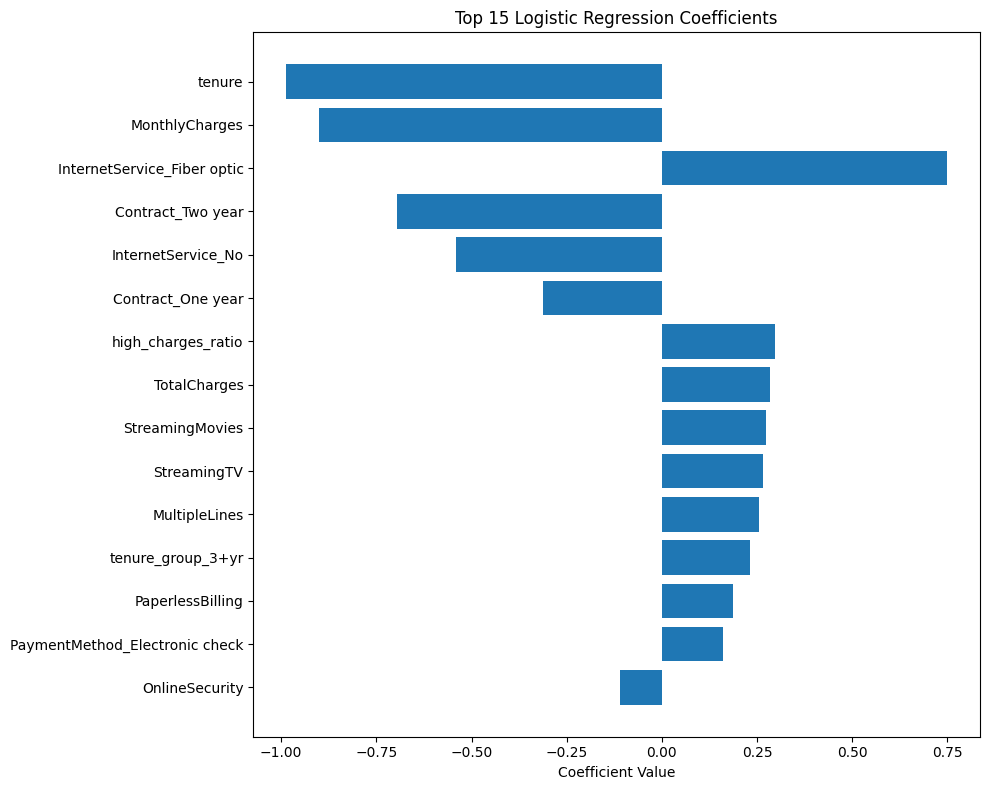


Evaluation plots saved


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve, auc, classification_report, roc_auc_score)
from sklearn.model_selection import train_test_split
import joblib

#Load model and data
df = pd.read_csv('../data/processed/featured_churn_data.csv')
X = df.drop('Churn', axis=1)
y = df['Churn']

#From previous tran/test split code
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = joblib.load('../data/models/scaler.pkl')
X_test_scaled = scaler.transform(X_test)

best_model = joblib.load('../data/models/best_model.pkl')
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print("---- Model Evaluation ----\n")

#1. Classification report
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

#2. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix:")
print(f"TN={cm[0,0]}, FP={cm[0,1]}")
print(f"FN={cm[1,0]}, TP={cm[1,1]}")

#3 Confusion matrix plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=300)
plt.close()

#4 ROC curve
fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC Curve')
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig('../data/roc_curve.png', dpi=300)
plt.close()

#5. Feature importance (for tree-based models)
if hasattr(best_model, 'coef_'):
    
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'coefficient': best_model.coef_[0]
    })

    # Ordenar por magnitud absoluta
    feature_importance['abs_coef'] = feature_importance['coefficient'].abs()

    feature_importance = feature_importance.sort_values(
        'abs_coef',
        ascending=False
    )

    print("\nTop 15 Most Important Features:")
    print(feature_importance[['feature', 'coefficient']].head(15))
    top_features = feature_importance.head(15)

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.barh(
        top_features['feature'],
        top_features['coefficient']
    )

    ax.set_title(
        'Top 15 Logistic Regression Coefficients'
    )

    ax.set_xlabel('Coefficient Value')

    ax.invert_yaxis()

    plt.tight_layout()

    plt.savefig(
        '../data/logistic_feature_importance.png',
        dpi=300
    )

    plt.show()

# 6. Prediction Distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(y_pred_proba[y_test==0], bins=30, alpha=0.6, label='No Churn (actual)')
ax.hist(y_pred_proba[y_test==1], bins=30, alpha=0.6, label='Churn (actual)')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Count')
ax.set_title('Distribution of Predicted Churn Probability')
ax.legend()
plt.tight_layout()
plt.savefig('../data/prediction_distribution.png', dpi=300)
plt.close()

print("\nEvaluation plots saved")